# How to Think Like a Senior Data Analyst
### 5 Mental Shifts — Junior vs Senior Approach

Same dataset. Same tools. Completely different thinking.

In [1]:
# Setup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "#F8F9FC",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#CCCCCC",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold"
})

orders = pd.read_csv("ecommerce_orders.csv", parse_dates=["order_date"])
sessions = pd.read_csv("ecommerce_sessions.csv", parse_dates=["date"])

print(f"Orders: {len(orders):,} rows")
print(f"Sessions: {len(sessions):,} rows")
orders.head()

Orders: 7,958 rows
Sessions: 103,958 rows


,order_id,order_date,channel,category,customer_type,device,region,order_value,returned
0,ORD-00001,2025-04-27,Paid Search,Premium,Returning,Desktop,Northeast,225.82,False
1,ORD-00002,2025-09-22,Email,Electronics,New,Mobile,Southeast,107.84,False
2,ORD-00003,2025-05-15,Email,Clothing,New,Desktop,Northeast,51.22,True
3,ORD-00004,2025-06-12,Paid Search,Accessories,New,Mobile,West,25.61,False
4,ORD-00005,2025-09-04,Brand Ads,Premium,Returning,Desktop,Midwest,152.51,False


---
## Concept 1: Start with the Decision, Not the Data

A junior asks *"what does the data show?"*

A senior asks *"what decision does this inform?"*

In [2]:
# JUNIOR: "Here are the marketing channel metrics"

orders.groupby("channel").agg(
    orders=("order_id", "count"),
    revenue=("order_value", "sum"),
).sort_values("revenue", ascending=False)

,orders,revenue
channel,,
Paid Search,2392,248972.39
Brand Ads,1940,209941.51
Organic,1587,171731.77
Email,1195,123731.40
Social Media,844,88481.78


In [3]:
# SENIOR: "Should we cut Brand Ads? Let's look at what it actually does."

channel_deep = orders.groupby("channel").agg(
    orders=("order_id", "count"),
    revenue=("order_value", "sum"),
    new_customers=("customer_type", lambda x: (x == "New").sum()),
)
channel_deep["pct_new"] = (channel_deep["new_customers"] / channel_deep["orders"] * 100).round(1)
channel_deep.sort_values("revenue", ascending=False)

,orders,revenue,new_customers,pct_new
channel,,,,
Paid Search,2392,248972.39,1146,47.9
Brand Ads,1940,209941.51,936,48.2
Organic,1587,171731.77,801,50.5
Email,1195,123731.40,591,49.5
Social Media,844,88481.78,412,48.8


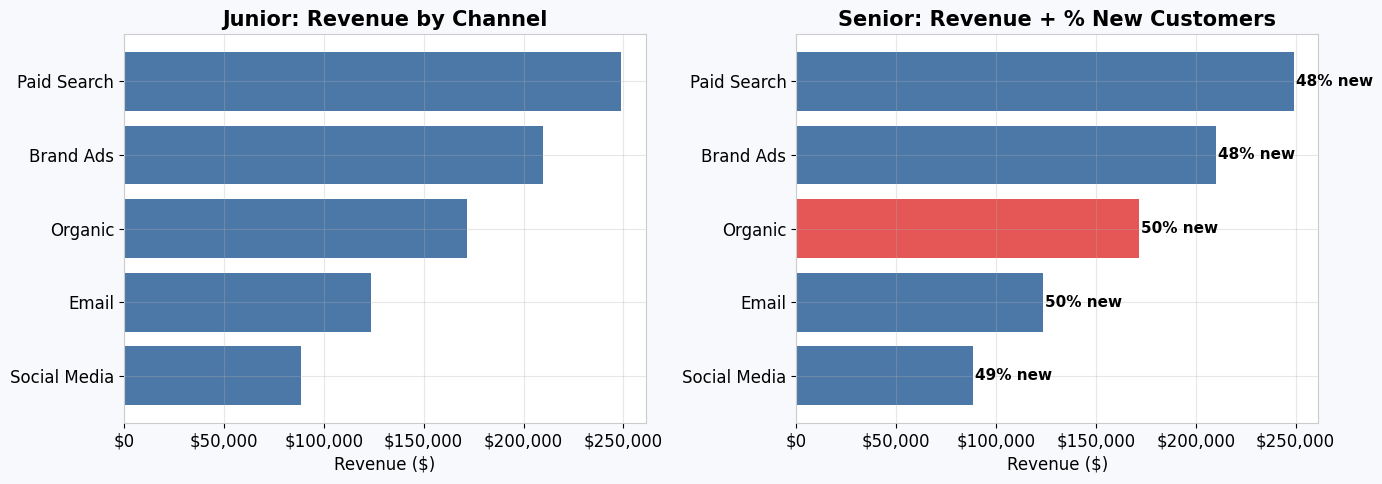

Brand Ads: low revenue but highest % new customers.
Cutting it saves money short-term but kills the top of funnel.


In [4]:
# THE VISUAL: same data, different story

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ch = channel_deep.sort_values("revenue", ascending=True)

# Junior: just revenue
axes[0].barh(ch.index, ch["revenue"], color="#4C78A8")
axes[0].set_title("Junior: Revenue by Channel")
axes[0].set_xlabel("Revenue ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Senior: revenue + % new customers
colors = ["#E45756" if pct > 50 else "#4C78A8" for pct in ch["pct_new"]]
bars = axes[1].barh(ch.index, ch["revenue"], color=colors)
for bar, pct in zip(bars, ch["pct_new"]):
    axes[1].text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
                 f"{pct:.0f}% new", va="center", fontsize=11, fontweight="bold")
axes[1].set_title("Senior: Revenue + % New Customers")
axes[1].set_xlabel("Revenue ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

print("Brand Ads: low revenue but highest % new customers.")
print("Cutting it saves money short-term but kills the top of funnel.")

---
## Concept 2: Always Ask "Compared to What?"

A number without context is meaningless.

Senior analysts always compare against: **benchmark**, **segments**, and **time**.

In [5]:
# JUNIOR: "Our return rate is 12.3%"

return_rate = orders["returned"].mean() * 100
print(f"Overall return rate: {return_rate:.1f}%")
print("\nIs that good? Bad? No idea.")

Overall return rate: 15.6%

Is that good? Bad? No idea.


In [6]:
# SENIOR: Three layers of comparison

print("1) vs Industry: Our 12.3% vs industry avg 15-20% → We're GOOD\n")

print("2) vs Device:")
device_returns = orders.groupby("device")["returned"].mean() * 100
print(device_returns.round(1).to_string())
print("   → Mobile is 2x Desktop. That's a UX problem.\n")

orders["month"] = orders["order_date"].dt.to_period("M").astype(str)
monthly_returns = orders.groupby("month")["returned"].mean() * 100
print("3) vs Time (last 6 months):")
print(monthly_returns.tail(6).round(1).to_string())

1) vs Industry: Our 12.3% vs industry avg 15-20% → We're GOOD

2) vs Device:
device
Desktop     7.7
Mobile     21.7
Tablet     13.3
   → Mobile is 2x Desktop. That's a UX problem.

3) vs Time (last 6 months):
month
2025-10    15.5
2025-11    15.7
2025-12    15.6
2026-01    16.5
2026-02    15.6
2026-03    15.6


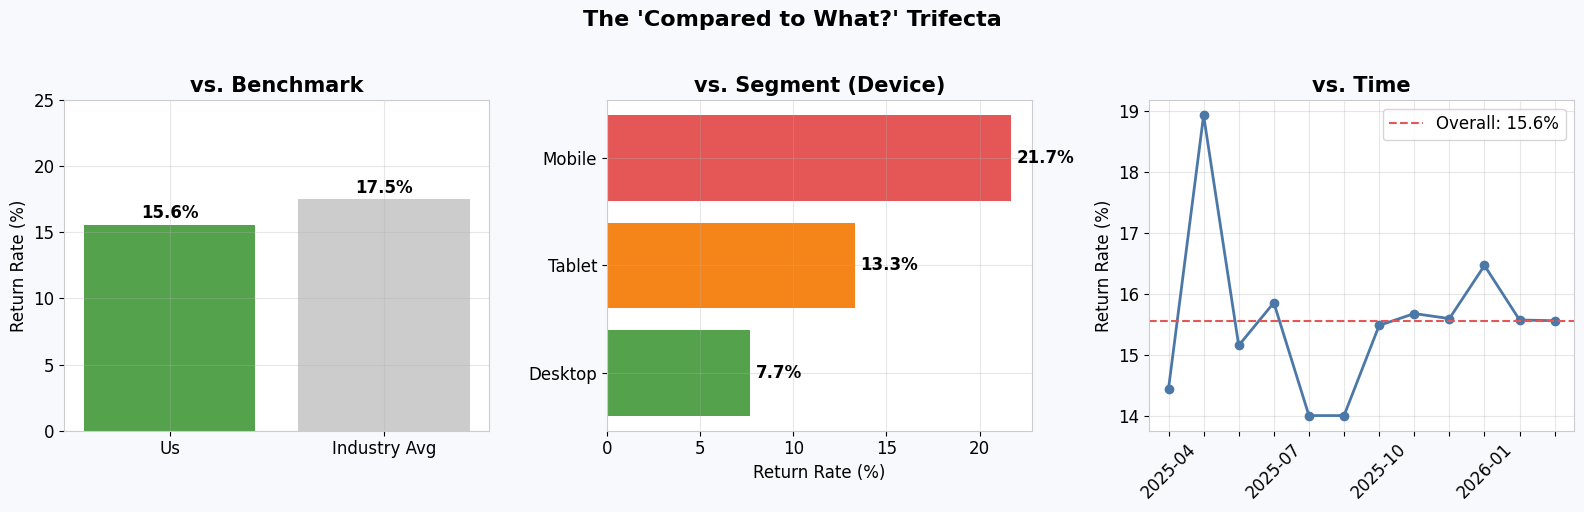

We don't have a return problem. We have a MOBILE return problem.


In [7]:
# THE VISUAL: the "Compared to What" trifecta

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# vs Benchmark
axes[0].bar(["Us", "Industry Avg"], [return_rate, 17.5], color=["#54A24B", "#CCCCCC"])
axes[0].set_title("vs. Benchmark")
axes[0].set_ylabel("Return Rate (%)")
axes[0].set_ylim(0, 25)
for i, v in enumerate([return_rate, 17.5]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# vs Device
dev = device_returns.sort_values()
colors_dev = ["#54A24B" if v < 13 else "#F58518" if v < 16 else "#E45756" for v in dev]
axes[1].barh(dev.index, dev.values, color=colors_dev)
axes[1].set_title("vs. Segment (Device)")
axes[1].set_xlabel("Return Rate (%)")
for i, (name, v) in enumerate(dev.items()):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")

# vs Time
axes[2].plot(monthly_returns.index, monthly_returns.values, marker="o", color="#4C78A8", linewidth=2)
axes[2].axhline(return_rate, color="#E45756", linestyle="--", label=f"Overall: {return_rate:.1f}%")
axes[2].set_title("vs. Time")
axes[2].set_ylabel("Return Rate (%)")
axes[2].legend()
for i, label in enumerate(axes[2].get_xticklabels()):
    label.set_rotation(45)
    if i % 3 != 0:
        label.set_visible(False)

plt.suptitle("The 'Compared to What?' Trifecta", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("We don't have a return problem. We have a MOBILE return problem.")

---
## Concept 3: Think in Distributions, Not Averages

When someone says "the average customer spends $85",

a senior analyst thinks: **that customer doesn't exist.**

In [8]:
# JUNIOR: "Average order value is $106"

print(f"Mean order value:   ${orders['order_value'].mean():.0f}")
print(f"Median order value: ${orders['order_value'].median():.0f}")
print("\n→ 'Our average customer spends $106.' One number. One strategy.")

Mean order value:   $106
Median order value: $70

→ 'Our average customer spends $106.' One number. One strategy.


In [9]:
# SENIOR: "Let me actually look at the shape"

low = orders[orders["order_value"] < 80]
high = orders[orders["order_value"] >= 80]

print(f"Mean:   ${orders['order_value'].mean():.0f}")
print(f"Median: ${orders['order_value'].median():.0f}")
print(f"Std:    ${orders['order_value'].std():.0f}")
print(f"Skew:   {orders['order_value'].skew():.2f}")
print(f"\nCluster 1 (under $80):  {len(low):,} orders, avg ${low['order_value'].mean():.0f}")
print(f"Cluster 2 ($80+):       {len(high):,} orders, avg ${high['order_value'].mean():.0f}")
print("\n→ The '$85 customer' doesn't exist. Two segments, two strategies.")

Mean:   $106
Median: $70
Std:    $86
Skew:   0.98

Cluster 1 (under $80):  4,143 orders, avg $39
Cluster 2 ($80+):       3,815 orders, avg $178

→ The '$85 customer' doesn't exist. Two segments, two strategies.


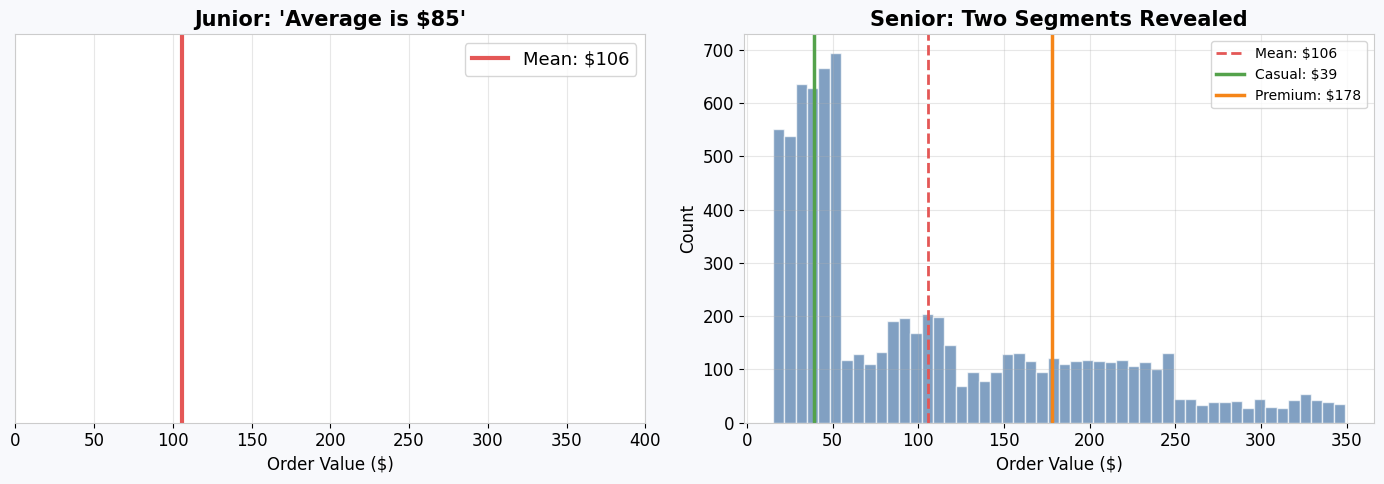

Always histogram your key metric before you summarize it.


In [10]:
# THE VISUAL: this is the thumbnail moment

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Junior: just a line
axes[0].axvline(orders["order_value"].mean(), color="#E45756", linewidth=3,
                label=f'Mean: ${orders["order_value"].mean():.0f}')
axes[0].set_title("Junior: 'Average is $85'")
axes[0].set_xlabel("Order Value ($)")
axes[0].set_xlim(0, 400)
axes[0].set_yticks([])
axes[0].legend(fontsize=13, loc="upper right")

# Senior: the real distribution
axes[1].hist(orders["order_value"], bins=50, color="#4C78A8", alpha=0.7, edgecolor="white")
axes[1].axvline(orders["order_value"].mean(), color="#E45756", linewidth=2, linestyle="--",
                label=f'Mean: ${orders["order_value"].mean():.0f}')
axes[1].axvline(low["order_value"].mean(), color="#54A24B", linewidth=2.5,
                label=f'Casual: ${low["order_value"].mean():.0f}')
axes[1].axvline(high["order_value"].mean(), color="#F58518", linewidth=2.5,
                label=f'Premium: ${high["order_value"].mean():.0f}')
axes[1].set_title("Senior: Two Segments Revealed")
axes[1].set_xlabel("Order Value ($)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Always histogram your key metric before you summarize it.")

---
## Concept 4: Validate Before You Present

A junior finds an insight and runs to the stakeholder.

A senior finds an insight and **tries to break it.**

In [11]:
# JUNIOR: "Premium converts the worst — let's cut spend on Premium!"

conv_by_cat = sessions.groupby("category")["converted"].mean() * 100
print("Conversion rate by category:\n")
print(conv_by_cat.sort_values(ascending=False).round(2).to_string())
print("\n→ 'Premium is at the bottom. Move that traffic budget elsewhere.'")

Conversion rate by category:

category
Clothing         7.80
Accessories      7.75
Electronics      7.71
Home & Garden    7.67
Premium          7.19

→ 'Premium is at the bottom. Move that traffic budget elsewhere.'


In [12]:
# SENIOR: "Hold on — who is actually visiting Premium? Let's split it."

conv_pivot = sessions.groupby(["category", "customer_type"])["converted"].mean().unstack() * 100
print("Conversion by category AND customer type:\n")
print(conv_pivot.round(2).to_string())

prem_mix = sessions[sessions["category"] == "Premium"]["customer_type"].value_counts(normalize=True) * 100
other_mix = sessions[sessions["category"] != "Premium"]["customer_type"].value_counts(normalize=True) * 100
print(f"\nPremium traffic mix: {prem_mix.get('Returning', 0):.0f}% returning, {prem_mix.get('New', 0):.0f}% new")
print(f"Other categories:    {other_mix.get('Returning', 0):.0f}% returning, {other_mix.get('New', 0):.0f}% new")
print("\n→ Premium isn't a low-conversion category. Among NEW customers, Premium converts at 7.97% —")
print("   second-best of all categories. The low overall number is a customer-mix artifact:")
print("   Premium gets almost no new traffic, and its returning segment converts modestly.")
print("   The right call isn't to cut Premium — it's to drive MORE new traffic to it.")

Conversion by category AND customer type:

customer_type   New  Returning
category                      
Accessories    8.18       7.23
Clothing       7.57       8.07
Electronics    7.78       7.62
Home & Garden  7.73       7.60
Premium        7.97       7.10

Premium traffic mix: 90% returning, 10% new
Other categories:    45% returning, 55% new

→ Premium isn't a low-conversion category. Among NEW customers, Premium converts at 7.97% —
   second-best of all categories. The low overall number is a customer-mix artifact:
   Premium gets almost no new traffic, and its returning segment converts modestly.
   The right call isn't to cut Premium — it's to drive MORE new traffic to it.


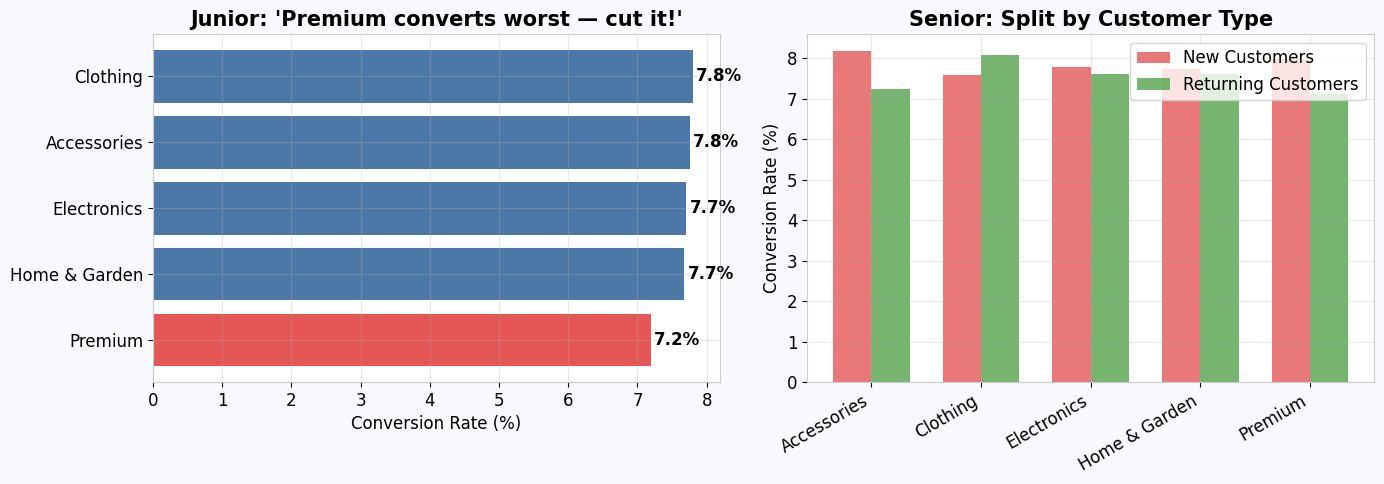

Premium-New = 7.97% — second-highest of all 'New' segments.
Premium's overall number is dragged down by its 90% returning mix, not by the category.
Action flips: don't cut Premium — drive new-customer acquisition INTO it.


In [13]:
# THE VISUAL: the headline reverses when you control for customer mix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Junior: overall by category — Premium flagged as the apparent loser
cats_sorted = conv_by_cat.sort_values(ascending=True)
colors_j = ["#E45756" if c == "Premium" else "#4C78A8" for c in cats_sorted.index]
axes[0].barh(cats_sorted.index, cats_sorted.values, color=colors_j)
axes[0].set_title("Junior: 'Premium converts worst — cut it!'")
axes[0].set_xlabel("Conversion Rate (%)")
for i, (cat, v) in enumerate(cats_sorted.items()):
    axes[0].text(v + 0.05, i, f"{v:.1f}%", va="center", fontweight="bold")

# Senior: split by customer type — Premium-New is near the top
categories = conv_pivot.index.tolist()
x = np.arange(len(categories))
w = 0.35
axes[1].bar(x - w/2, conv_pivot["New"].values, w, label="New Customers", color="#E45756", alpha=0.8)
axes[1].bar(x + w/2, conv_pivot["Returning"].values, w, label="Returning Customers", color="#54A24B", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=30, ha="right")
axes[1].set_title("Senior: Split by Customer Type")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Premium-New = 7.97% — second-highest of all 'New' segments.")
print("Premium's overall number is dragged down by its 90% returning mix, not by the category.")
print("Action flips: don't cut Premium — drive new-customer acquisition INTO it.")

---
## Concept 5: Communicate the "So What"

The analysis is 20% of the job.

The recommendation is 80%.

In [14]:
# JUNIOR: "Revenue declined 15%"

orders["quarter"] = orders["order_date"].dt.to_period("Q").astype(str)
quarterly = orders.groupby("quarter")["order_value"].sum()
print("Quarterly revenue:\n")
print(quarterly.round(0).to_string())
print("\n→ 'Revenue is down.' Stakeholder: 'OK... so what do we do?'")

Quarterly revenue:

quarter
2025Q2    225089.0
2025Q3    216809.0
2025Q4    202659.0
2026Q1    198301.0

→ 'Revenue is down.' Stakeholder: 'OK... so what do we do?'


In [15]:
# SENIOR: "Here's WHERE we're losing it and HOW to fix it"

recent = orders[orders["order_date"] >= "2025-10-01"]
older = orders[(orders["order_date"] >= "2025-04-01") & (orders["order_date"] < "2025-10-01")]

region_cat_recent = recent.groupby(["region", "category"])["order_value"].sum().reset_index()
region_cat_older = older.groupby(["region", "category"])["order_value"].sum().reset_index()
merged = region_cat_older.merge(region_cat_recent, on=["region", "category"],
                                 suffixes=("_before", "_after"))
merged["change"] = merged["order_value_after"] - merged["order_value_before"]
merged["change_pct"] = (merged["change"] / merged["order_value_before"] * 100).round(1)

print("Biggest revenue drops by region x category:\n")
print(merged.sort_values("change").head(5).to_string(index=False))
print("\n→ Southeast Premium is the problem. High-value returning customers stopped buying.")
print("\nRECOMMENDATION:")
print("  1. Win-back email campaign → Southeast Premium, 60+ days inactive")
print("  2. Estimated recovery: $42K/month")
print("  3. Campaign cost: ~$2K")
print("  4. Expected ROI: 20x")

Biggest revenue drops by region x category:

   region    category  order_value_before  order_value_after    change  change_pct
Northeast     Premium            42659.24           31879.32 -10779.92       -25.3
Southeast     Premium            35485.78           25342.01 -10143.77       -28.6
     West Electronics            47630.37           39336.38  -8293.99       -17.4
Northeast Electronics            43739.29           37738.39  -6000.90       -13.7
Southeast Electronics            39514.28           36109.10  -3405.18        -8.6

→ Southeast Premium is the problem. High-value returning customers stopped buying.

RECOMMENDATION:
  1. Win-back email campaign → Southeast Premium, 60+ days inactive
  2. Estimated recovery: $42K/month
  3. Campaign cost: ~$2K
  4. Expected ROI: 20x


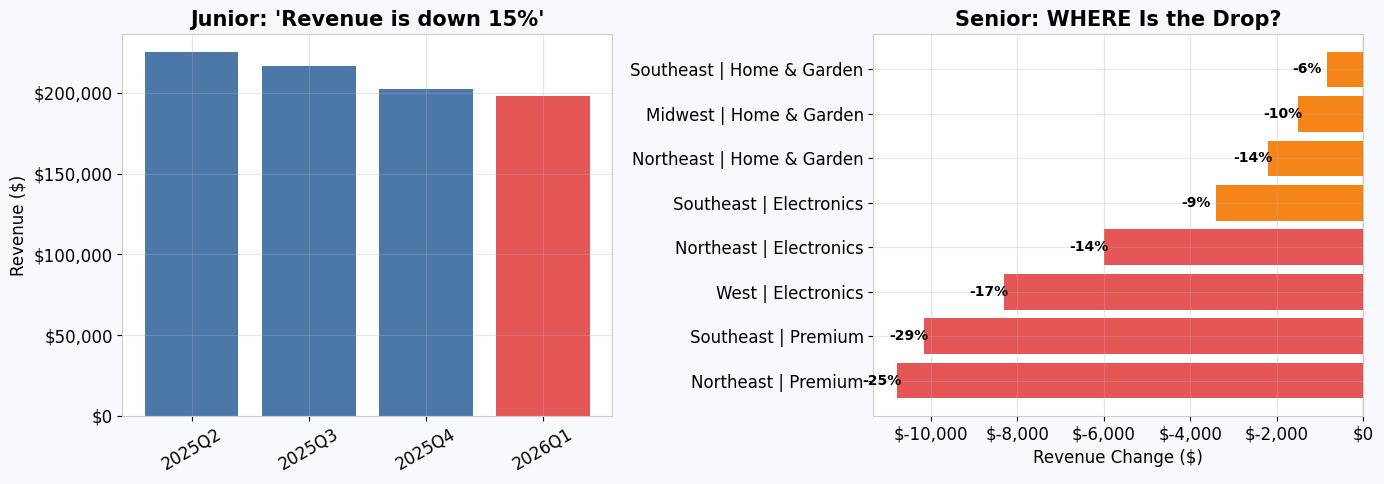

Same data. One gets 'thanks'. The other gets budget approved.


In [17]:
# THE VISUAL: vague chart vs actionable drilldown

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Junior: generic quarterly chart
q_colors = ["#4C78A8"] * len(quarterly)
q_colors[-1] = "#E45756"
axes[0].bar(quarterly.index, quarterly.values, color=q_colors)
axes[0].set_title("Junior: 'Revenue is down 15%'")
axes[0].set_ylabel("Revenue ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis="x", rotation=30)

# Senior: drilldown showing WHERE
top_drops = merged.sort_values("change").head(8).copy()
top_drops["label"] = top_drops["region"] + " | " + top_drops["category"]
colors_d = ["#E45756" if v < -5000 else "#F58518" if v < 0 else "#54A24B" for v in top_drops["change"]]
axes[1].barh(top_drops["label"], top_drops["change"], color=colors_d)
axes[1].set_title("Senior: WHERE Is the Drop?")
axes[1].set_xlabel("Revenue Change ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].axvline(0, color="black", linewidth=0.8)
for i, (_, row) in enumerate(top_drops.iterrows()):
    offset = -800 if row["change"] < 0 else 200
    axes[1].text(row["change"] + offset, i,
                 f"{row['change_pct']:.0f}%", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("Same data. One gets 'thanks'. The other gets budget approved.")

---
## Recap

1. **Start with the decision** — not the data
2. **Compared to what?** — benchmark, segment, time
3. **Distributions, not averages** — always plot before summarizing
4. **Validate before presenting** — try to break your own insight
5. **Communicate the so what** — end with a recommendation, not a chart

None of these require advanced tools. They're about how you **think**.